# **Soliton Solutions to the Korteweg–De Vries (KdV) equation**

Here presents the differences in functionality between the legacy KdV PINN and the current refactored version

**Setup:**

In [1]:
import torch
import torch.nn as nn

import sys
from pathlib import Path

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))

from models import KDV

Check GPU availability:

In [2]:
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

CUDA available: True


# One Soliton

Configure and train a model for a single soliton, showing model initialization, training, testing, solution computation and plotting

In [3]:
INIT_PARAMS = dict(
    num_solitons             = 1,
    n_hidden_layers          = 4, 
    n_neurons_per_layer      = 32, 
    activation               = nn.Tanh,
    seed                     = 72, 
    verbose                  = True,
)

TRAIN_PARAMS = dict(
    adam_epochs              = 1000,
    verbose_step             = 100,
    n_collocation            = 50000, 
    n_initial                = 30000,  
    n_boundary               = 10000,     
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 1.0,    
    lbfgs_history_size       = 100, 
    lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
    adaptive_sampling        = True,   
    logging                  = True, #new parameter, stops loss logging bottleneck for quick training (no loss history)
)

TRAIN_WEIGHTS = dict( #seperated out from the train params
    w_ic                     = 5.0,    
    w_bc                     = 1.0,    
    w_pde                    = 15.0, 
)

Create an instance of the class:

In [4]:
model = KDV(INIT_PARAMS)

Using device: cuda


Train the model:

In [5]:
training_stats, domain = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS) #renamed to not conflict with nn.Module superclass allows other integrations

/home/jairdan/miniconda3/envs/soliton-pinns/lib/python3.14/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/home/jairdan/soliton-pinns/models/kdv_2/loss.py:141: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses['total'].append(float(total_loss))


Weighted losses [start]: IC=3.540e-01 | BC=8.423e-02 | PDE=8.985e-02
Starting Adam optimization...
[gpu mem] train start               alloc   717.7 MB  reserved   808.0 MB  peak   717.7 MB
Adam - Epoch 0/1000, Total Loss: 5.281108e-01
Adam - Epoch 100/1000, Total Loss: 7.818272e-03
Adam - Epoch 200/1000, Total Loss: 3.309340e-03
Adam - Epoch 300/1000, Total Loss: 1.471215e-03
Adam - Epoch 400/1000, Total Loss: 6.875439e-04
Adam - Epoch 500/1000, Total Loss: 3.816359e-04
Adam - Epoch 600/1000, Total Loss: 2.458506e-04
Adam - Epoch 700/1000, Total Loss: 1.791304e-04
Adam - Epoch 800/1000, Total Loss: 1.431968e-04
Adam - Epoch 900/1000, Total Loss: 1.215410e-04
Adam - Epoch 999/1000, Total Loss: 1.070149e-04
[gpu mem] after Adam                alloc    18.9 MB  reserved  1570.0 MB  peak  1431.9 MB
Performing adaptive sampling...
Collocation points from 50000 -> 100000

Starting L-BFGS optimization...
L-BFGS - Iteration 100, Total Loss: 5.200150e-05
L-BFGS - Iteration 200, Total Loss: 1.6

Plot the losses using the new returned dataclasses:  
(This was done so that loss histories can be saved and plotted again later much more easily)

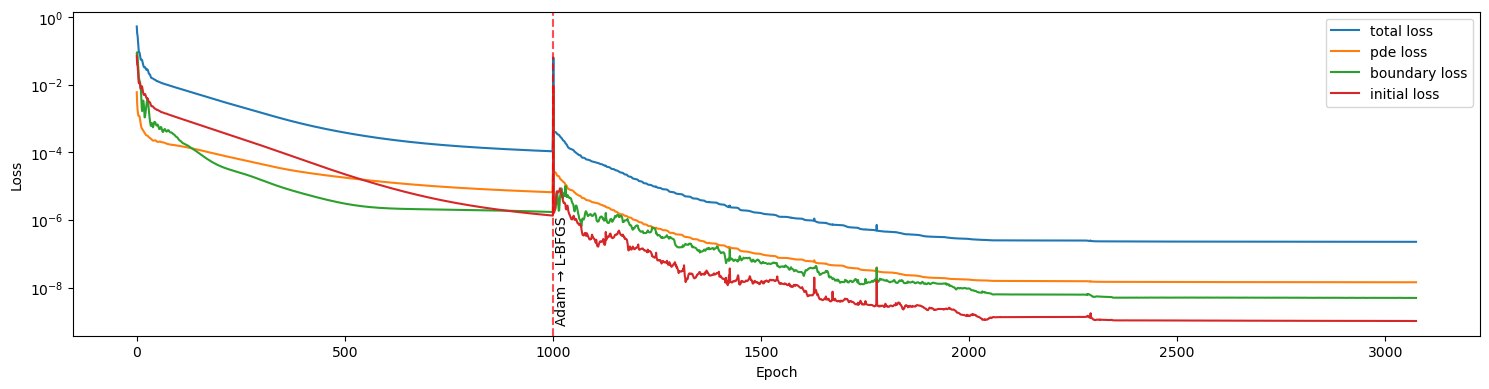

In [6]:
plot_loss = model.plot_losses(training_stats)

Plot the profiles (Automatic Run):

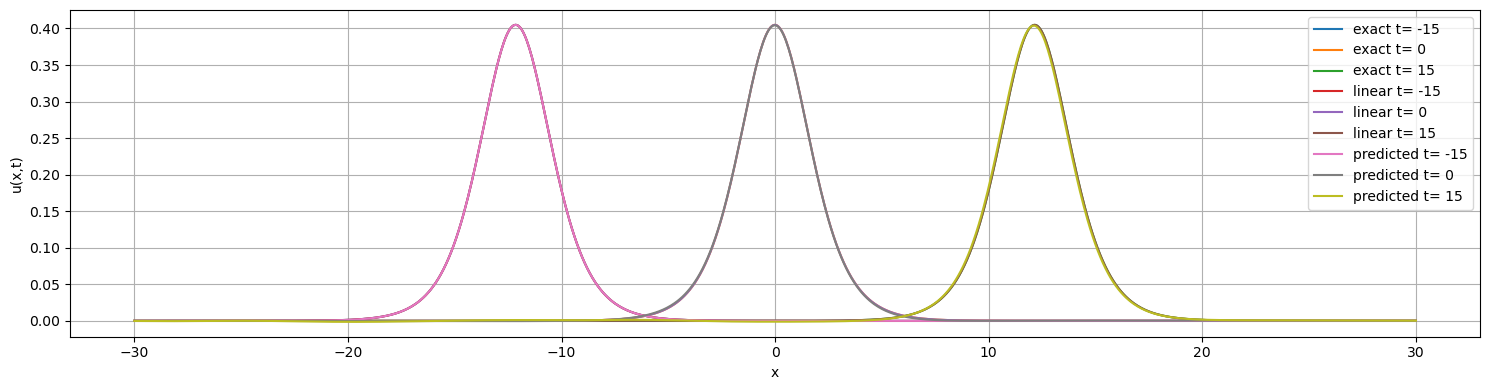

In [7]:
plot_auto_prof = model.plot_profiles(t_values=[-15, 0, 15], which=('exact', 'linear', 'predicted')) #visualization functions now use OOP, returning a savable figure

Plot the profiles (Precomputed Solution):

In [8]:
#UNDERCONSTRUCTION

Plot the spacetime (Automatic Run):

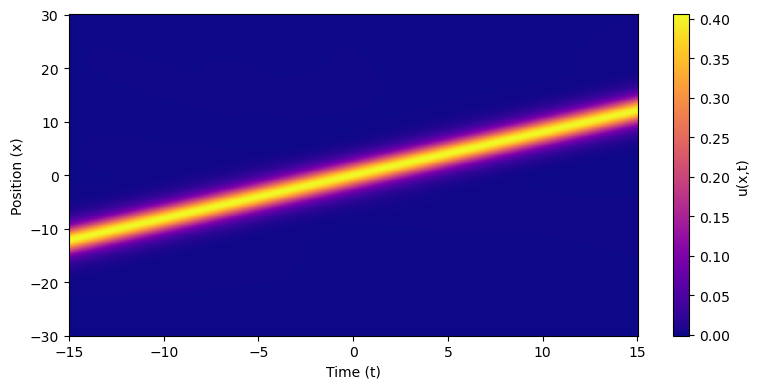

In [9]:
plot_auto_st = model.plot_spacetime()

Plot the spacetime w/ scatter (Automatic Run):

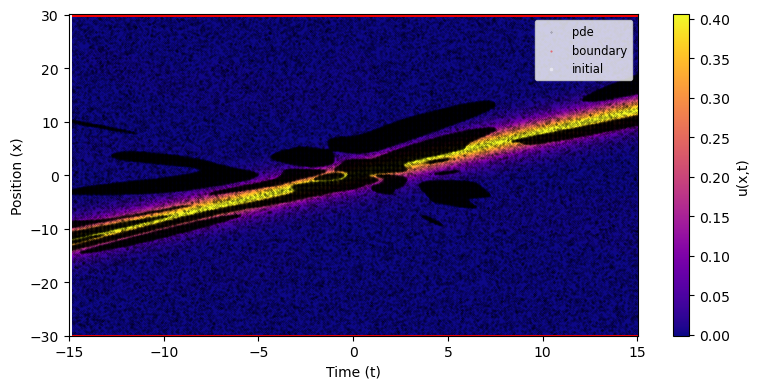

In [10]:
plot_auto_sst = model.plot_spacetime(scatter_which=('pde', 'boundary', 'initial'), training_domain=domain)

Plot the spacetime (Precomputed Solution):

In [11]:
#UNDERCONSTRUCTION

Plot the spacetime w/ scatter (Precomputed Solution):

In [12]:
#UNDERCONSTRUCTION

Now that the solutions have been visualized, test how accurate they are:  
The error type `absolute` and `absolute-normalized` are retained

In [13]:
error_stats = model.test()

absolute-normalized error metrics:
Mean: 1.168940e-03
Maximum: 1.485098e-02


The plot heat map function is now a separate call

absolute-normalized error metrics:
Mean: 1.168940e-03
Maximum: 1.485098e-02


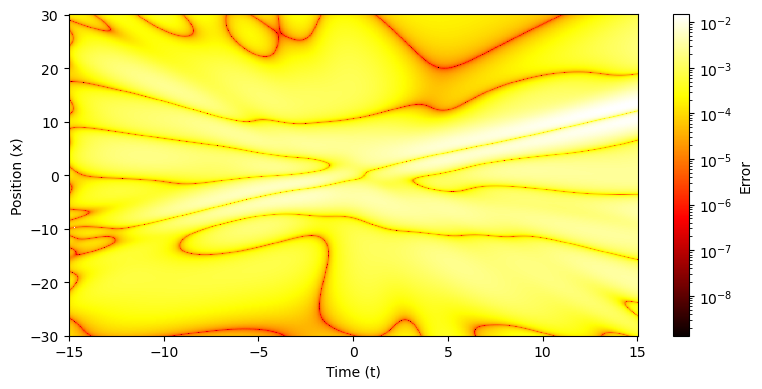

In [14]:
plot_err = model.plot_heatmap()